# Chapter 11 Companion — Unsteady Turbulent Channel Flow

**Principles of Turbulence: Theory and Physical Insight with Python Companion Computations**  
**Chapter 11: Unsteady Turbulent Channel Flow**

This notebook accompanies the chapter on periodically forced turbulent channel flow. It is designed to connect the governing equations, time-scale arguments, phase averaging, triple decomposition, and rough-wall response regimes with reproducible computational diagnostics.

The notebook uses synthetic and DNS-inspired data. It is not intended to replace direct numerical simulation; rather, it provides controlled examples that help interpret the physics of oscillatory and pulsatile turbulent flows.


## Learning Objectives

By the end of this notebook, the reader should be able to:

1. Generate and interpret time-periodic pressure-gradient forcing.
2. Decompose a velocity signal into long-time mean, coherent oscillatory, and stochastic turbulent components.
3. Compute oscillatory penetration depth and Stokes-layer scaling.
4. Identify low-, intermediate-, and high-frequency regimes using time-scale ratios.
5. Interpret smooth- and rough-wall mean velocity shifts using the roughness function \(\Delta U^+\).
6. Analyze amplitude attenuation and phase lag of the coherent velocity response.
7. Interpret phase-dependent Reynolds-stress modulation and turbulent memory.
8. Examine a harmonic turbulent kinetic energy response model.


## Notebook Structure

1. Setup and notation  
2. Time-periodic pressure-gradient forcing  
3. Phase averaging and triple decomposition  
4. Characteristic time scales and nondimensional groups  
5. Regime map for unsteady turbulence  
6. Velocity structure: smooth and rough log laws  
7. Rough-wall mean velocity deficit under unsteady forcing  
8. Oscillatory mean velocity: amplitude and phase lag  
9. Phase response of Reynolds shear stress  
10. Harmonic TKE response and turbulent memory  
11. Summary exercises


In [1]:
# ============================================================
# 1. Setup and plotting defaults
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "lines.linewidth": 2.0,
})

# Output directory for figures generated by this notebook
FIG_DIR = Path("chapter11_figures")
FIG_DIR.mkdir(exist_ok=True)

print("Notebook setup complete.")


Notebook setup complete.


---

## 2. Time-Periodic Pressure-Gradient Forcing

The canonical pressure-gradient forcing used in the chapter is

\[
-\frac{1}{\rho}\frac{\partial P}{\partial x}(t)
=G_0+G_1\cos(\omega t),
\]

where \(G_0\) is the steady component, \(G_1\) is the oscillatory amplitude, and \(\omega\) is the forcing frequency.


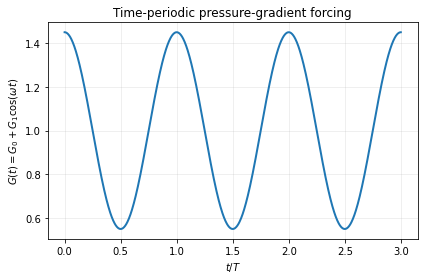

In [2]:
# ============================================================
# 2. Time-periodic forcing
# ============================================================
G0 = 1.0
G1 = 0.45
omega = 2*np.pi  # one cycle per unit time
T = 2*np.pi/omega

t = np.linspace(0, 3*T, 900)
forcing = G0 + G1*np.cos(omega*t)

plt.figure()
plt.plot(t/T, forcing)
plt.xlabel(r"$t/T$")
plt.ylabel(r"$G(t)=G_0+G_1\cos(\omega t)$")
plt.title("Time-periodic pressure-gradient forcing")
plt.tight_layout()
plt.savefig(FIG_DIR/"pressure_gradient_forcing.png", dpi=200)
plt.show()


---

## 3. Phase Averaging and Triple Decomposition

For periodically forced turbulence, the instantaneous velocity can be decomposed as

\[
u_i = U_i + \widetilde{u}_i + u_i'',
\]

where \(U_i\) is the long-time or cycle-averaged mean, \(\widetilde{u}_i\) is the coherent phase-locked component, and \(u_i''\) is the residual turbulent fluctuation about the phase-dependent mean.

The following synthetic signal illustrates the decomposition at a fixed wall-normal location.


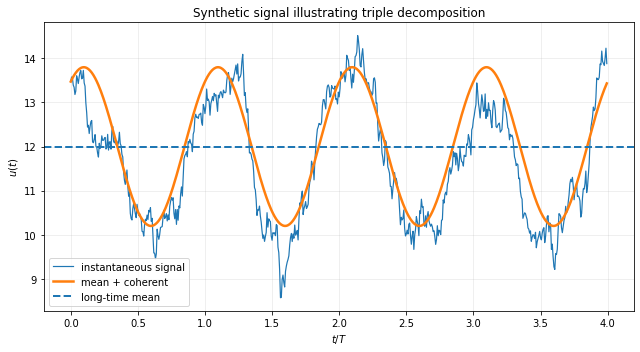

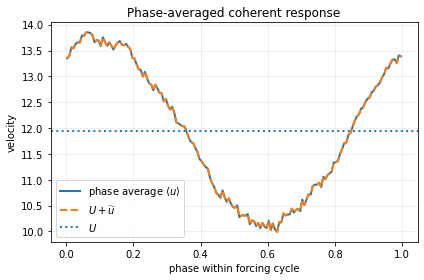

In [3]:
# ============================================================
# 3. Synthetic triple decomposition
# ============================================================
rng = np.random.default_rng(7)
U_mean = 12.0
A_coh = 1.8
phi = np.deg2rad(35)

n_cycles = 20
samples_per_cycle = 160
T = 1.0
omega = 2*np.pi/T

t = np.linspace(0, n_cycles*T, n_cycles*samples_per_cycle, endpoint=False)
coherent = A_coh*np.cos(omega*t - phi)

# stochastic turbulent residual with mild correlation
noise = rng.normal(0, 0.55, len(t))
residual = np.zeros_like(noise)
alpha = 0.92
for i in range(1, len(t)):
    residual[i] = alpha*residual[i-1] + np.sqrt(1-alpha**2)*noise[i]

u_total = U_mean + coherent + residual

# Estimate phase average by binning within cycle
phase = (t % T)/T
bins = np.linspace(0, 1, samples_per_cycle+1)
phase_centers = 0.5*(bins[:-1]+bins[1:])
phase_avg = np.zeros(samples_per_cycle)
for j in range(samples_per_cycle):
    mask = (phase >= bins[j]) & (phase < bins[j+1])
    phase_avg[j] = u_total[mask].mean()

U_est = u_total.mean()
coherent_est = phase_avg - U_est

plt.figure(figsize=(9, 5))
plt.plot(t[:4*samples_per_cycle]/T, u_total[:4*samples_per_cycle], lw=1.2, label="instantaneous signal")
plt.plot(t[:4*samples_per_cycle]/T, U_mean + coherent[:4*samples_per_cycle], lw=2.5, label="mean + coherent")
plt.axhline(U_mean, ls="--", label="long-time mean")
plt.xlabel(r"$t/T$")
plt.ylabel(r"$u(t)$")
plt.title("Synthetic signal illustrating triple decomposition")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"triple_decomposition_signal.png", dpi=200)
plt.show()

plt.figure()
plt.plot(phase_centers, phase_avg, label=r"phase average $\langle u\rangle$")
plt.plot(phase_centers, U_est + coherent_est, "--", label=r"$U+\widetilde{u}$")
plt.axhline(U_est, ls=":", label=r"$U$")
plt.xlabel("phase within forcing cycle")
plt.ylabel("velocity")
plt.title("Phase-averaged coherent response")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"phase_average_coherent_response.png", dpi=200)
plt.show()


---

## 4. Characteristic Time Scales and Scaling Parameters

The key scales introduced in the chapter are collected here as the single source of notation:

\[
t_\omega=\frac{1}{\omega},\qquad
 t_c=\frac{H}{U_b},\qquad
 t_\nu=\frac{H^2}{\nu},
\]

\[
t_R\sim \frac{\nu}{u_\tau^2},\qquad
 t_k\sim \frac{k}{u_\tau},\qquad
 \delta_s=\sqrt{\frac{2\nu}{\omega}}.
\]

The nondimensional parameters are

\[
Re_b=\frac{U_b H}{\nu},\qquad
St=\frac{\omega H}{U_b},\qquad
\alpha=H\sqrt{\frac{\omega}{\nu}},\qquad
k^+=\frac{k u_\tau}{\nu}.
\]


In [4]:
# ============================================================
# 4. Time-scale calculator
# ============================================================
def compute_time_scales(H=1.0, Ub=1.0, nu=1/180, utau=1.0, k=0.05, omega=1.0):
    t_omega = 1/omega
    t_c = H/Ub
    t_nu = H**2/nu
    t_R = nu/utau**2
    t_k = k/utau
    delta_s = np.sqrt(2*nu/omega)
    Re_b = Ub*H/nu
    St = omega*H/Ub
    alpha = H*np.sqrt(omega/nu)
    k_plus = k*utau/nu
    return {
        "t_omega": t_omega,
        "t_c": t_c,
        "t_nu": t_nu,
        "t_R": t_R,
        "t_k": t_k,
        "delta_s": delta_s,
        "delta_s/k": delta_s/k,
        "Re_b": Re_b,
        "St": St,
        "alpha": alpha,
        "k_plus": k_plus,
    }

scales = compute_time_scales(H=1.0, Ub=1.0, nu=1/180, utau=1.0, k=0.08, omega=1.0)
pd.DataFrame(scales, index=["value"]).T


,value
t_omega,1.000000
t_c,1.000000
t_nu,180.000000
t_R,0.005556
t_k,0.080000
delta_s,0.105409
delta_s/k,1.317616
Re_b,180.000000
St,1.000000
alpha,13.416408


### Parameter sweep: penetration depth

The oscillatory penetration depth decreases as forcing frequency increases:

\[
\delta_s\propto \omega^{-1/2}.
\]


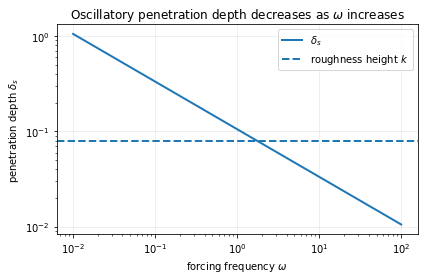

In [5]:
omega_values = np.logspace(-2, 2, 200)
nu = 1/180
k = 0.08
delta_s = np.sqrt(2*nu/omega_values)

plt.figure()
plt.loglog(omega_values, delta_s, label=r"$\delta_s$")
plt.axhline(k, ls="--", label=r"roughness height $k$")
plt.xlabel(r"forcing frequency $\omega$")
plt.ylabel(r"penetration depth $\delta_s$")
plt.title(r"Oscillatory penetration depth decreases as $\omega$ increases")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"penetration_depth_vs_frequency.png", dpi=200)
plt.show()


---

## 5. Regime Map for Periodically Forced Turbulence

The flow response is organized by the ratios \(t_\omega/t_R\) and \(t_\omega/t_c\). Low-frequency forcing corresponds to slow variation relative to turbulence response, intermediate forcing produces non-equilibrium behavior, and high-frequency forcing confines the coherent response toward the wall.


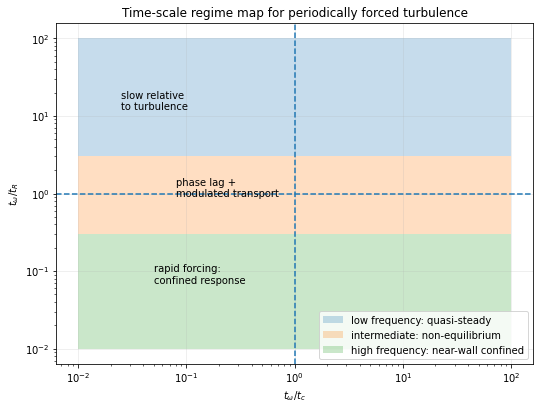

In [6]:
# ============================================================
# 5. Regime map
# ============================================================
x = np.logspace(-2, 2, 300)  # t_omega/t_c

y_low = np.ones_like(x)*3

y_high = np.ones_like(x)*0.3

plt.figure(figsize=(7.6, 5.8))
plt.fill_between(x, y_low, 100, alpha=0.25, label="low frequency: quasi-steady")
plt.fill_between(x, y_high, y_low, alpha=0.25, label="intermediate: non-equilibrium")
plt.fill_between(x, 1e-2, y_high, alpha=0.25, label="high frequency: near-wall confined")
plt.axhline(1, ls="--", lw=1.5)
plt.axvline(1, ls="--", lw=1.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$t_\omega/t_c$")
plt.ylabel(r"$t_\omega/t_R$")
plt.title("Time-scale regime map for periodically forced turbulence")
plt.text(0.025, 12, "slow relative\nto turbulence", fontsize=10)
plt.text(0.08, 0.9, "phase lag +\nmodulated transport", fontsize=10)
plt.text(0.05, 0.07, "rapid forcing:\nconfined response", fontsize=10)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR/"regime_map_timescales.png", dpi=200)
plt.show()


---

## 6. Velocity Structure: Smooth and Rough Log Laws

The smooth-wall logarithmic law is

\[
U^+=\frac{1}{\kappa}\ln y^+ + B.
\]

For rough-wall turbulence, the profile is displaced downward by the roughness function:

\[
U^+=\frac{1}{\kappa}\ln y^+ + B - \Delta U^+.
\]

Under periodic forcing, \(\Delta U^+\) can become frequency and phase dependent because coherent oscillatory motion modifies near-wall momentum transport.


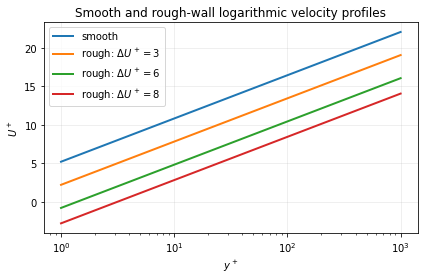

In [7]:
# ============================================================
# 6. Smooth and rough log laws
# ============================================================
kappa = 0.41
B = 5.2
yplus = np.logspace(0, 3, 300)
U_smooth = 1/kappa*np.log(yplus) + B

DeltaU_values = [0.0, 3.0, 6.0, 8.0]
labels = [r"smooth", r"rough: $\Delta U^+=3$", r"rough: $\Delta U^+=6$", r"rough: $\Delta U^+=8$"]

plt.figure()
for DU, lab in zip(DeltaU_values, labels):
    plt.semilogx(yplus, U_smooth-DU, label=lab)
plt.xlabel(r"$y^+$")
plt.ylabel(r"$U^+$")
plt.title("Smooth and rough-wall logarithmic velocity profiles")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"smooth_rough_log_laws.png", dpi=200)
plt.show()


---

## 7. Rough-Wall Mean Velocity Deficit Under Unsteady Forcing

The following synthetic DNS-inspired profiles illustrate how increasing forcing frequency can increase the apparent roughness shift. The high-frequency case produces the strongest downward displacement of the log-law region.


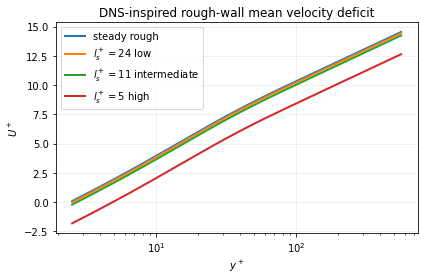

In [8]:
# ============================================================
# 7. DNS-inspired mean velocity profiles
# ============================================================
yplus = np.logspace(0.4, 2.75, 220)
U_log = 1/kappa*np.log(yplus) + B

cases = {
    r"steady rough": 6.1,
    r"$l_s^+=24$ low": 6.2,
    r"$l_s^+=11$ intermediate": 6.4,
    r"$l_s^+=5$ high": 8.0,
}

plt.figure()
for label, DU in cases.items():
    # add small smooth curvature near low y+ to mimic real profiles
    U = U_log - DU - 1.5*np.exp(-yplus/15)
    plt.semilogx(yplus, U, label=label)
plt.xlabel(r"$y^+$")
plt.ylabel(r"$U^+$")
plt.title(r"DNS-inspired rough-wall mean velocity deficit")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"roughwall_mean_velocity_deficit.png", dpi=200)
plt.show()


---

## 8. Oscillatory Mean Velocity: Amplitude and Phase Lag

For a coherent velocity component dominated by the fundamental harmonic,

\[
\widetilde{U}(y,t)=A_{\widetilde U}(y)
\cos\left[\omega t-\phi_{\widetilde U}(y)\right].
\]

The normalized amplitude \(A_{\widetilde U}/A_{\widetilde U_c}\) measures wall-normal penetration, while the relative phase \(\phi_{\widetilde U}-\phi_{\widetilde U_c}\) measures local delay or advance relative to the centerline response.


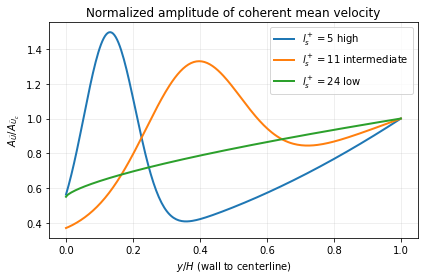

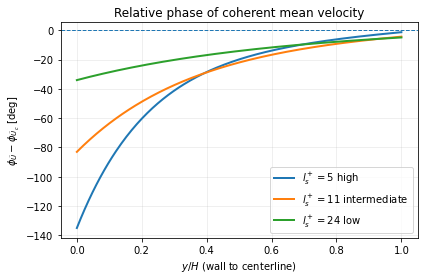

In [9]:
# ============================================================
# 8. Synthetic amplitude and phase response
# ============================================================
y = np.linspace(0, 1, 250)  # normalized half-channel coordinate, wall=0, center=1

# DNS-inspired amplitude shapes
amp_high = 0.25 + 1.15*np.exp(-((y-0.13)/0.11)**2) + 0.7*y**1.7
amp_high /= amp_high[-1]

amp_mid = 0.35 + 0.75*np.exp(-((y-0.38)/0.20)**2) + 0.65*y**1.1
amp_mid /= amp_mid[-1]

amp_low = 0.55 + 0.45*y**0.7
amp_low /= amp_low[-1]

phase_high = -120*np.exp(-y/0.22) + 15*(y-1)
phase_mid = -75*np.exp(-y/0.35) + 8*(y-1)
phase_low = -30*np.exp(-y/0.55) + 4*(y-1)

plt.figure()
plt.plot(y, amp_high, label=r"$l_s^+=5$ high")
plt.plot(y, amp_mid, label=r"$l_s^+=11$ intermediate")
plt.plot(y, amp_low, label=r"$l_s^+=24$ low")
plt.xlabel(r"$y/H$ (wall to centerline)")
plt.ylabel(r"$A_{\widetilde U}/A_{\widetilde U_c}$")
plt.title("Normalized amplitude of coherent mean velocity")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"oscillatory_velocity_amplitude.png", dpi=200)
plt.show()

plt.figure()
plt.plot(y, phase_high, label=r"$l_s^+=5$ high")
plt.plot(y, phase_mid, label=r"$l_s^+=11$ intermediate")
plt.plot(y, phase_low, label=r"$l_s^+=24$ low")
plt.axhline(0, lw=1, ls="--")
plt.xlabel(r"$y/H$ (wall to centerline)")
plt.ylabel(r"$\phi_{\widetilde U}-\phi_{\widetilde U_c}$ [deg]")
plt.title("Relative phase of coherent mean velocity")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"oscillatory_velocity_phase.png", dpi=200)
plt.show()


---

## 9. Phase Response of Reynolds Shear Stress

The Reynolds shear stress \(-\langle u''v''\rangle\) measures turbulent transport of streamwise momentum. Under periodic forcing, it becomes phase dependent. A simple harmonic representation is

\[
R_{uv}(y,t)=R_0(y)+A_{uv}(y)\cos[\omega t-\phi_{uv}(y)]+\cdots.
\]

The phase \(\phi_{uv}\) quantifies turbulent memory: Reynolds stress may lag the coherent mean response because production, redistribution, and dissipation require finite adjustment time.


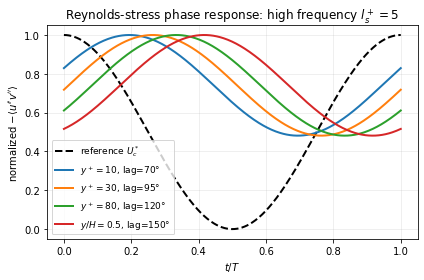

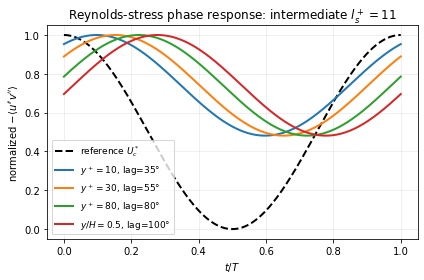

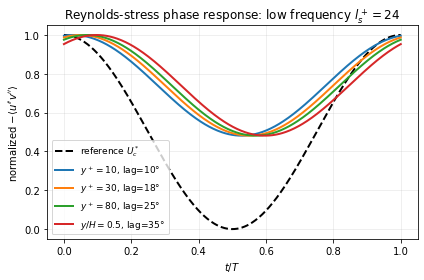

In [14]:
# ============================================================
# 9. Reynolds-stress phase response at selected wall-normal locations
# ============================================================
phase = np.linspace(0, 1, 400)
theta = 2*np.pi*phase
Uc = 0.5 + 0.5*np.cos(theta)  # normalized reference signal

def normalized_rs(theta, lag_deg, modulation=0.35):
    lag = np.deg2rad(lag_deg)
    raw = 1.0 + modulation*np.cos(theta-lag)
    return raw/raw.max()

locations = [r"$y^+=10$", r"$y^+=30$", r"$y^+=80$", r"$y/H=0.5$"]
lag_sets = {
    r"high frequency $l_s^+=5$": [70, 95, 120, 150],
    r"intermediate $l_s^+=11$": [35, 55, 80, 100],
    r"low frequency $l_s^+=24$": [10, 18, 25, 35],
}

for title, lags in lag_sets.items():
    plt.figure()
    plt.plot(phase, Uc, "k--", label=r"reference $U_c^*$")
    for loc, lag in zip(locations, lags):
        plt.plot(phase, normalized_rs(theta, lag), label=loc + f", lag={lag}°")
    plt.xlabel(r"$t/T$")
    plt.ylabel(r"normalized $-\langle u''v''\rangle$")
    plt.title("Reynolds-stress phase response: " + title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    fname = title.replace(" ", "_").replace("$", "").replace("^", "").replace("+", "plus").replace("=", "")
    plt.savefig(FIG_DIR/("reynolds_stress_phase_" + fname + ".png"), dpi=200)
    plt.show()


---

## 10. Harmonic TKE Response and Turbulent Memory

A simplified phase-averaged turbulent kinetic energy balance can be written as

\[
\frac{\partial k}{\partial t}=P-\varepsilon-\frac{\partial T}{\partial y}.
\]

For a fundamental harmonic response,

\[
i\omega K_1=P_1-\varepsilon_1-\partial_y T_1.
\]

If the unsteady inertial term dominates, then

\[
|K_1|\sim \frac{|P_1|}{\omega},
\]

and the oscillatory TKE lags production by approximately \(90^\circ\).


In [ ]:
# ============================================================
# 10. Simple first-order TKE response model
# ============================================================
# Model: dk'/dt + k'/tau = P0*cos(omega t)/C
# Complex amplitude: K = P0 / (1/tau + i omega)

tau = 1.0
omega_sweep = np.logspace(-2, 2, 300)
K_amp = 1/np.sqrt((1/tau)**2 + omega_sweep**2)
phase_lag = np.rad2deg(np.arctan(omega_sweep*tau))

plt.figure()
plt.loglog(omega_sweep*tau, K_amp/K_amp[0])
plt.xlabel(r"$\omega t_R$")
plt.ylabel(r"normalized $|K_1|$")
plt.title("Attenuation of oscillatory TKE response")
plt.tight_layout()
plt.savefig(FIG_DIR/"tke_response_amplitude.png", dpi=200)
plt.show()

plt.figure()
plt.semilogx(omega_sweep*tau, phase_lag)
plt.axhline(90, ls="--", lw=1)
plt.xlabel(r"$\omega t_R$")
plt.ylabel("phase lag [deg]")
plt.title("Phase lag of oscillatory TKE response")
plt.tight_layout()
plt.savefig(FIG_DIR/"tke_response_phase_lag.png", dpi=200)
plt.show()


---

## 11. Summary Exercises

1. Vary \(\omega\) in the time-scale calculator and identify when \(\delta_s/k\) becomes order unity.
2. Modify \(t_R\) in the regime map and describe how the low-, intermediate-, and high-frequency regions shift.
3. Increase \(\Delta U^+\) in the rough-wall mean velocity plot and explain how the log-law displacement changes.
4. Change the phase lags in the Reynolds-stress model and identify which case most closely resembles quasi-steady behavior.
5. Use the TKE response model to determine the frequency at which the oscillatory TKE amplitude falls below 25% of its low-frequency value.


## Notebook Closing Interpretation

Periodically forced turbulent channel flow is organized by the competition between imposed forcing and intrinsic turbulence response. The mean flow records the cycle-averaged modification of the velocity profile, the coherent component encodes amplitude attenuation and phase lag, and the turbulent fluctuations determine Reynolds-stress transport and TKE response. Roughness strengthens the near-wall interaction because coherent oscillatory motion can interact directly with roughness-generated vortices and separated flow when the penetration depth becomes comparable to the roughness height.
